In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [36]:
df=pd.read_csv("insurance (1).csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [37]:
df.shape

(1338, 7)

In [38]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [39]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


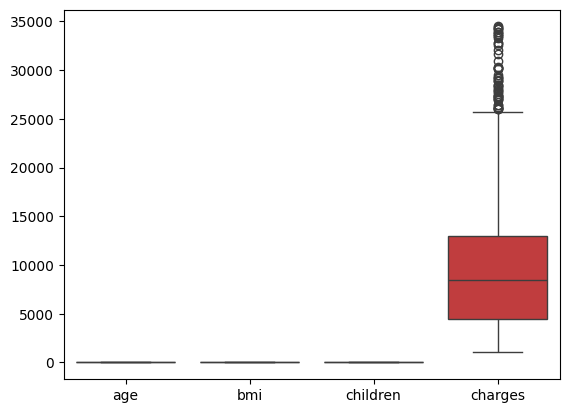

In [46]:
sns.boxplot(df)
plt.show()

In [50]:
Q1=df['charges'].quantile(0.25)
Q3=df['charges'].quantile(0.75) 
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['charges']>=lower_bound) & (df['charges']<=upper_bound)]

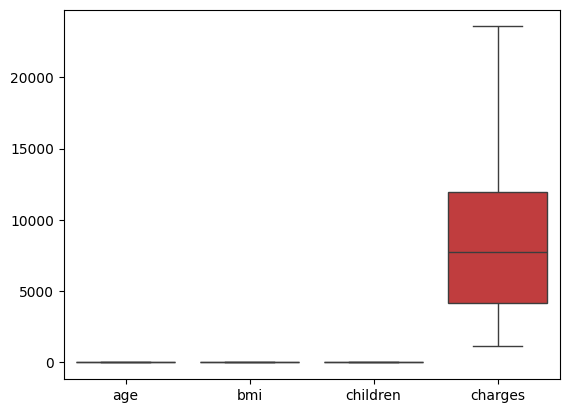

In [51]:
sns.boxplot(df)
plt.show()

In [52]:
X = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = df['charges']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

sc_X = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

sc_y = StandardScaler()

y_train = sc_y.fit_transform(
    y_train.values.reshape(-1,1)
).ravel()

model = SVR(
    kernel='rbf',
    C=1000,
    gamma=0.01,
    epsilon=0.1
)

model.fit(X_train, y_train)

y_pred_scaled = model.predict(X_test)

y_pred = sc_y.inverse_transform(
    y_pred_scaled.reshape(-1,1)
)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 8462843.721203849
R2 Score: 0.7199385961207307


In [55]:
import pickle
with open("svmreg.pkl","wb") as f:
    pickle.dump(model,f)
with open("scaler_X.pkl", "wb") as f:
    pickle.dump(sc_X, f)
with open("scaler_y.pkl", "wb") as f:
    pickle.dump(sc_y, f)